In [594]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [595]:
df = pd.read_csv('Obesity.csv')

In [596]:
df.head(73)

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,Male,30.0,1.76,112.0,yes,yes,1.0,3.0,no,yes,2.0,yes,0.0,0.0,Frequently,Automobile,Obesity_Type_II
69,Male,23.0,1.80,60.0,yes,no,2.0,3.0,no,no,3.0,no,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
70,Female,NaN,NaN,NaN,yes,yes,NaN,NaN,Always,no,NaN,no,NaN,NaN,no,Public_Transportation,Overweight_Level_II
71,Female,-22.0,-1.67,-50.0,yes,no,-3.0,-3.0,no,no,-3.0,yes,-2.0,-1.0,Sometimes,Public_Transportation,Insufficient_Weight


Exploring the Data: 
Here are the column names from the dataset, along with a brief description based on their names:

1. **Gender**: Indicates the gender of the individual i.e Male, Female.
2. **Age**: The age of the individual.
3. **Height**: The height of the individual, likely in centimeters or meters.
4. **Weight**: The weight of the individual, likely in kilograms or pounds.
5. **Family_history**: Indicates whether there is a family history of obesity or related health conditions.
6. **FAVC**: Refers to the Frequency of consumption of high-calorie foods.
7. **FCVC**: Frequency of vegetable consumption.
8. **NCP**: Possibly the number of meals consumed per day.
9. **CAEC**: May indicate the frequency of eating food outside of regular meals.
10. **SMOKE**: Indicates whether the individual smokes.
11. **CH2O**: Likely refers to daily water intake.
12. **SCC**: Could represent whether the individual monitors their calorie consumption.
13. **FAF**: Possibly the frequency of physical activity per week.
14. **TUE**: Could refer to the time spent using electronic devices or sedentary time.
15. **CALC**: May indicate alcohol consumption frequency.
16. **MTRANS**: Likely represents the mode of transportation used (e.g., walking, driving).
17. **Obesity**: Indicates the obesity status or level of the individual.

In [597]:
df.shape

(2111, 17)

<Axes: >

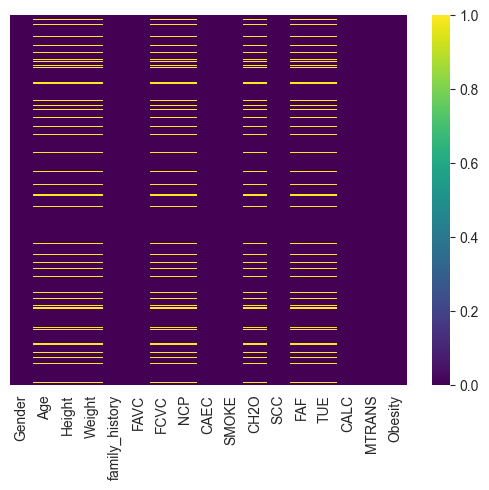

In [598]:
sns.heatmap(df.isnull(), yticklabels = False, cbar = True, cmap = 'viridis')

In [599]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             1903 non-null   float64
 2   Height          1903 non-null   float64
 3   Weight          1903 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            1903 non-null   float64
 7   NCP             1903 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            1903 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             1903 non-null   float64
 13  TUE             1903 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [600]:
df['Obesity'].unique()

array(['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II',
       'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II',
       'Obesity_Type_III'], dtype=object)

In [601]:
from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()

df['Gender']= label_encoder.fit_transform(df['Gender'])
df['family_history']= label_encoder.fit_transform(df['family_history'])
df['FAVC']= label_encoder.fit_transform(df['FAVC'])
df['CAEC']= label_encoder.fit_transform(df['CAEC'])
df['SMOKE']= label_encoder.fit_transform(df['SMOKE'])
df['SCC']= label_encoder.fit_transform(df['SCC'])
df['CALC']= label_encoder.fit_transform(df['CALC'])
df['MTRANS']= label_encoder.fit_transform(df['MTRANS'])
df['Obesity']= label_encoder.fit_transform(df['Obesity'])

In [602]:
df.corr(numeric_only=True) 

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
Gender,1.000000,0.029150,0.069420,0.073621,0.102512,0.064934,-0.114790,0.030162,0.091543,0.044698,0.052724,-0.102633,0.147577,0.020570,0.007616,-0.137537,0.024908
Age,0.029150,1.000000,0.839014,0.748823,0.106971,0.027965,0.754419,0.686150,0.046020,0.068642,0.671857,-0.069252,0.312772,0.213037,-0.032128,-0.304555,0.121216
Height,0.069420,0.839014,1.000000,0.836040,0.038838,0.026485,0.874542,0.833243,0.022127,0.025156,0.817165,-0.036759,0.483038,0.423288,-0.014422,-0.027869,0.011898
Weight,0.073621,0.748823,0.836040,1.000000,0.275893,0.153582,0.776924,0.700216,0.167206,0.032132,0.720045,-0.122668,0.334453,0.303883,-0.121410,-0.009103,0.211778
family_history,0.102512,0.106971,0.038838,0.275893,1.000000,0.208036,0.024851,0.046720,0.169787,0.017385,0.082081,-0.185422,-0.055090,0.041667,0.036676,-0.101540,0.313667
FAVC,0.064934,0.027965,0.026485,0.153582,0.208036,1.000000,-0.004228,0.012677,0.150068,-0.050660,0.012796,-0.190658,-0.084659,0.063815,-0.089520,-0.069800,0.044582
FCVC,-0.114790,0.754419,0.874542,0.776924,0.024851,-0.004228,1.000000,0.737356,-0.018531,0.023240,0.730907,0.012064,0.409487,0.331328,-0.032296,0.011755,0.007970
NCP,0.030162,0.686150,0.833243,0.700216,0.046720,0.012677,0.737356,1.000000,-0.027084,0.030016,0.684843,-0.034241,0.437033,0.360928,-0.033098,-0.045448,-0.042627
CAEC,0.091543,0.046020,0.022127,0.167206,0.169787,0.150068,-0.018531,-0.027084,1.000000,-0.055282,0.084571,-0.109179,-0.033019,-0.015232,-0.047540,-0.048535,0.327295
SMOKE,0.044698,0.068642,0.025156,0.032132,0.017385,-0.050660,0.023240,0.030016,-0.055282,1.000000,-0.012337,0.047731,0.024401,0.027347,-0.082471,-0.010702,-0.023256


<Axes: >

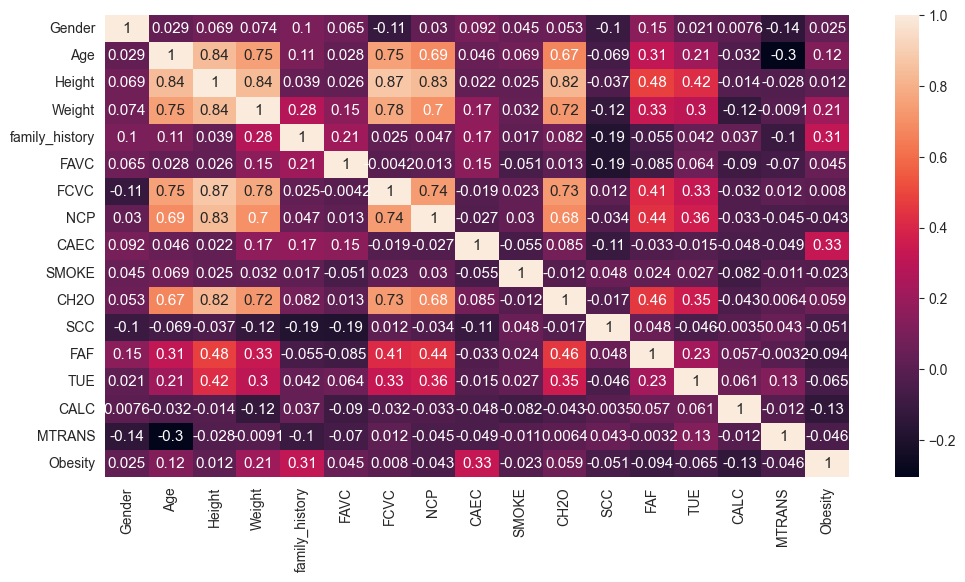

In [603]:
plt.figure(figsize = (12, 6))
sns.heatmap(df.corr(numeric_only=True) , annot = True, annot_kws = {"size":11})

<Axes: xlabel='Obesity', ylabel='count'>

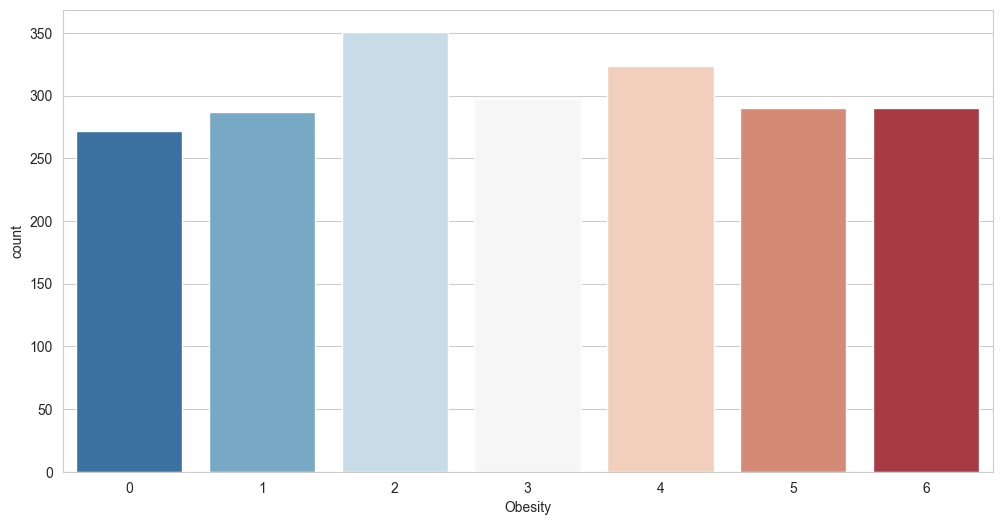

In [604]:
# sns.set_style('whitegrid')
# sns.countplot(x = 'Obesity', data = df_obese, palette = 'RdBu_r')

plt.figure(figsize=(12, 6)) 
sns.set_style('whitegrid')
sns.countplot(x='Obesity', data=df, palette='RdBu_r')

Here : 
0 -> 'Normal_Weight'
1 -> 'Overweight_Level_I'
2 -> 'Overweight_Level_II'
3 -> 'Obesity_Type_I'
4 -> 'Insufficient_Weight'
5 -> 'Obesity_Type_II'
6 -> 'Obesity_Type_III'

<Axes: xlabel='Obesity', ylabel='count'>

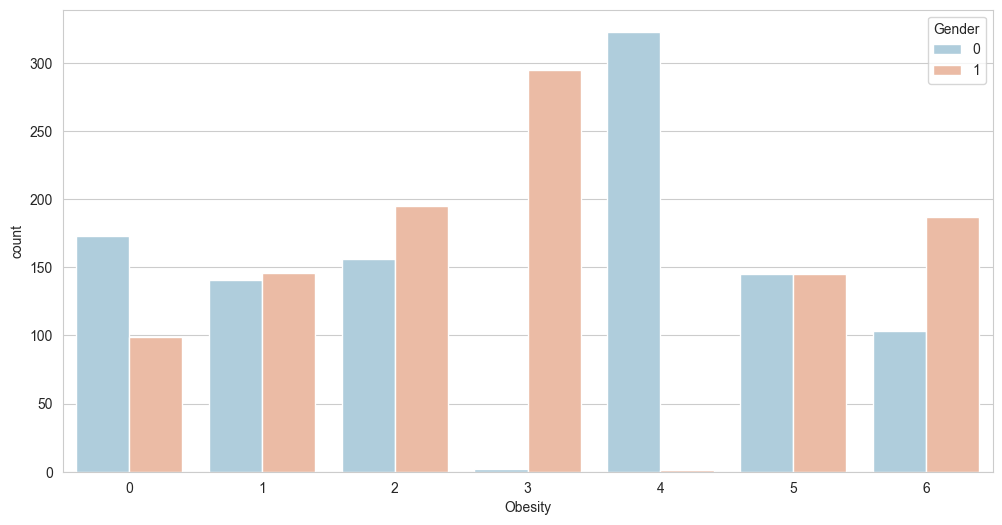

In [605]:
plt.figure(figsize=(12, 6)) 
sns.set_style('whitegrid')
sns.countplot(x = 'Obesity', hue = 'Gender', data = df, palette = 'RdBu_r')

<Axes: xlabel='Obesity', ylabel='count'>

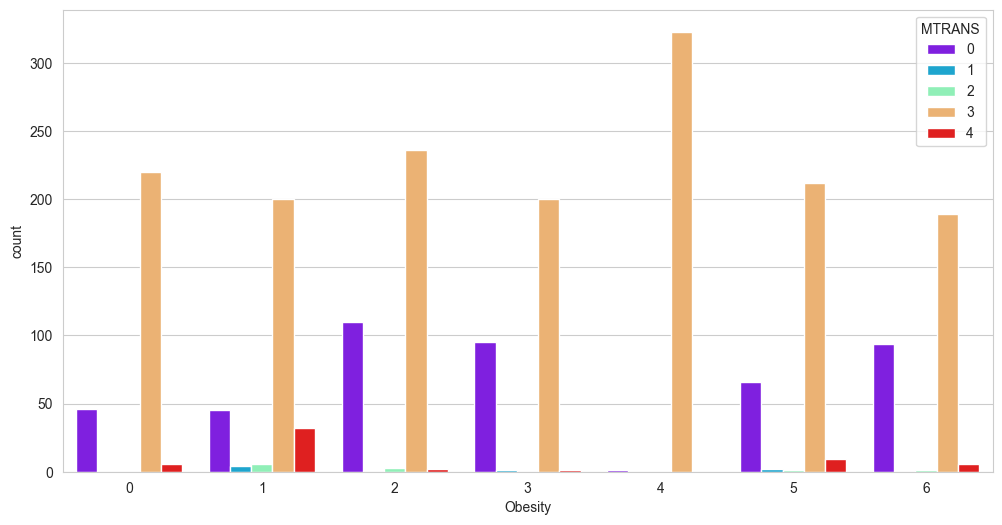

In [606]:
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')
sns.countplot(x = 'Obesity', hue = 'MTRANS', data = df, palette = 'rainbow')

<Axes: xlabel='Age'>

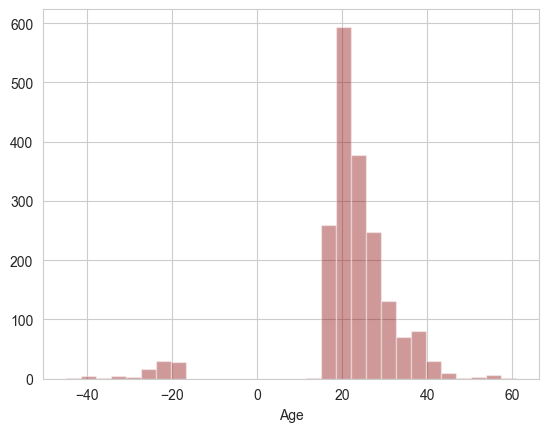

In [607]:
sns.distplot(df['Age'].dropna(), kde = False, color = 'darkred', bins = 30)


In [608]:
mean_age = round(df[df['Age'] > 0]['Age'].mean())
df['Age'] = df['Age'].apply(lambda x: x if x >= 0 else mean_age)
df.head(73)

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,0,21.0,1.62,64.0,1,0,2.0,3.0,2,0,2.0,0,0.0,1.0,3,3,1
1,0,21.0,1.52,56.0,1,0,3.0,3.0,2,1,3.0,1,3.0,0.0,2,3,1
2,1,23.0,1.80,77.0,1,0,2.0,3.0,2,0,2.0,0,2.0,1.0,1,3,1
3,1,27.0,1.80,87.0,0,0,3.0,3.0,2,0,2.0,0,2.0,0.0,1,4,5
4,1,22.0,1.78,89.8,0,0,2.0,1.0,2,0,2.0,0,0.0,0.0,2,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,1,30.0,1.76,112.0,1,1,1.0,3.0,3,1,2.0,1,0.0,0.0,1,0,3
69,1,23.0,1.80,60.0,1,0,2.0,3.0,3,0,3.0,0,0.0,1.0,2,3,1
70,0,24.0,NaN,NaN,1,1,NaN,NaN,0,0,NaN,0,NaN,NaN,3,3,6
71,0,24.0,-1.67,-50.0,1,0,-3.0,-3.0,3,0,-3.0,1,-2.0,-1.0,2,3,0


<Axes: xlabel='Age'>

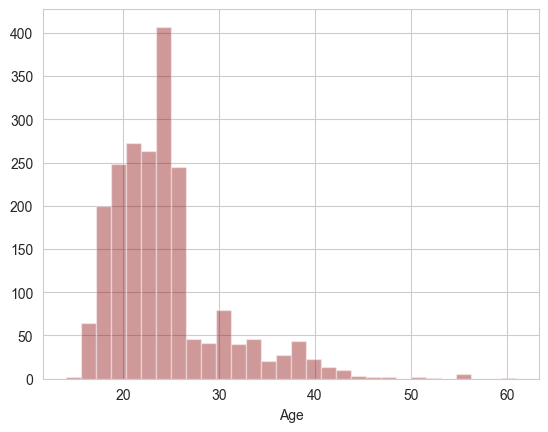

In [609]:
sns.distplot(df['Age'].dropna(), kde = False, color = 'darkred', bins = 30)


<Axes: xlabel='Weight'>

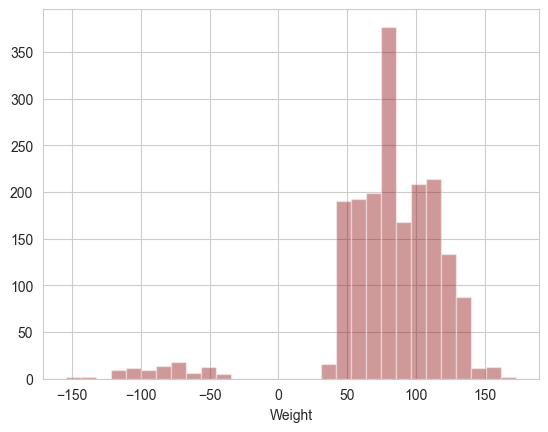

In [610]:
sns.distplot(df['Weight'].dropna(), kde = False, color = 'darkred', bins = 30)


In [611]:
count = sum(df['Weight'] < 0)
print(count)

89


89/2111*100 = 4.7% data is Negative

In [612]:
mean = round(df[df['Weight'] > 0]['Weight'].mean())
df['Weight'] = df['Weight'].apply(lambda x: x if x >= 0 else mean)


In [613]:
count = sum(df['Weight'] < 0)
print(count)

0


<Axes: xlabel='Weight'>

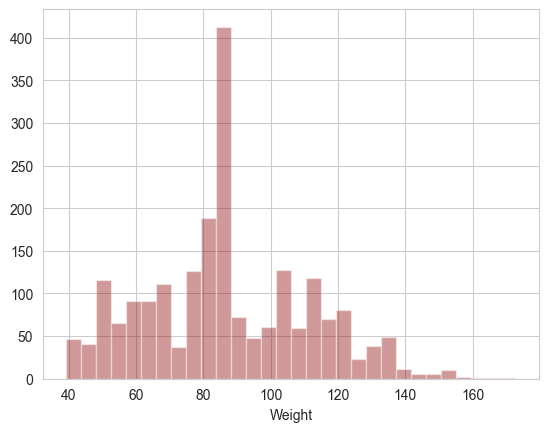

In [614]:
sns.distplot(df['Weight'].dropna(), kde = False, color = 'darkred', bins = 30)


1.5437388402522334


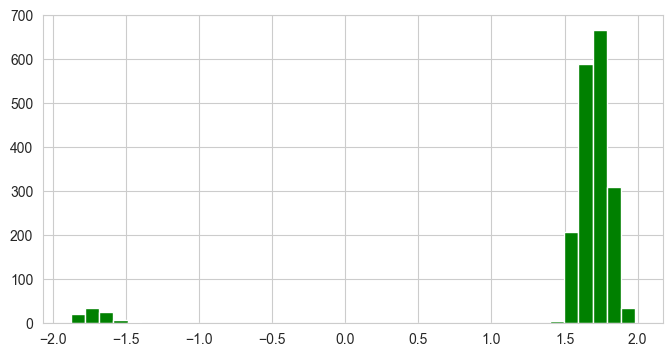

In [615]:
df['Height'].hist(color = 'green', bins = 40, figsize = (8, 4))
print(df['Height'].mean())

In [616]:
mean = round(df[df['Height'] > 0]['Height'].mean())
df['Height'] = df['Height'].apply(lambda x: x if x >= 0 else mean)
print(mean)


2


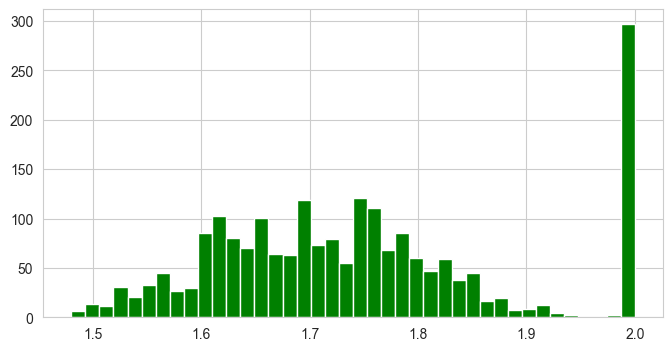

In [617]:
df['Height'].hist(color='green', bins=40, figsize=(8, 4))
plt.show()

<Axes: xlabel='Obesity', ylabel='Weight'>

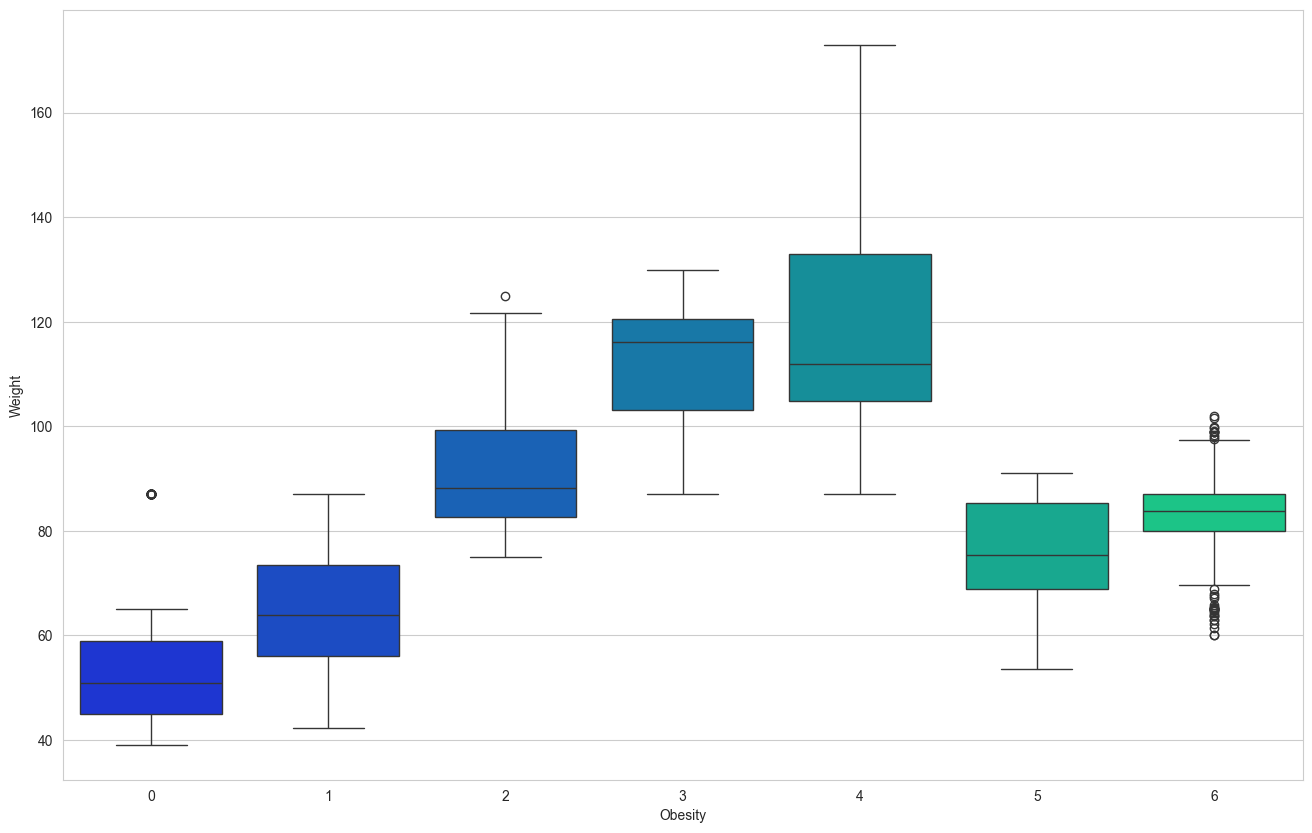

In [618]:
plt.figure(figsize = (16, 10))
sns.boxplot(x = 'Obesity', y = 'Weight', data = df, palette = 'winter')

In [619]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   int32  
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   int32  
 5   FAVC            2111 non-null   int32  
 6   FCVC            1903 non-null   float64
 7   NCP             1903 non-null   float64
 8   CAEC            2111 non-null   int32  
 9   SMOKE           2111 non-null   int32  
 10  CH2O            1903 non-null   float64
 11  SCC             2111 non-null   int32  
 12  FAF             1903 non-null   float64
 13  TUE             1903 non-null   float64
 14  CALC            2111 non-null   int32  
 15  MTRANS          2111 non-null   int32  
 16  Obesity         2111 non-null   int32  
dtypes: float64(8), int32(9)
memory us

<Axes: >

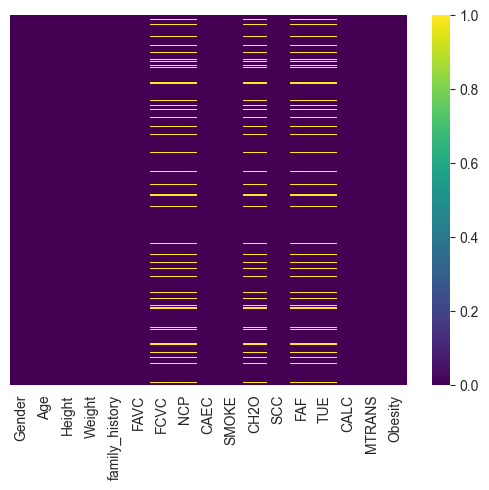

In [620]:
sns.heatmap(df.isnull(), yticklabels = False, cbar = True, cmap = 'viridis')

In [621]:
mean = df[df['NCP'] > 0]['NCP'].mean()
df['NCP'] = df['NCP'].apply(lambda x: x if x >= 0 else mean)
print(mean)

2.690171040793826


In [622]:
# numeric_cols = df.select_dtypes(include=np.number).columns
# mask = df[numeric_cols].lt(0).any(axis=1)
# df = df[~mask]
# df

In [623]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   int32  
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   int32  
 5   FAVC            2111 non-null   int32  
 6   FCVC            1903 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   int32  
 9   SMOKE           2111 non-null   int32  
 10  CH2O            1903 non-null   float64
 11  SCC             2111 non-null   int32  
 12  FAF             1903 non-null   float64
 13  TUE             1903 non-null   float64
 14  CALC            2111 non-null   int32  
 15  MTRANS          2111 non-null   int32  
 16  Obesity         2111 non-null   int32  
dtypes: float64(8), int32(9)
memory us

In [624]:
mean = round(df.loc[df['FCVC'] > 0, 'FCVC'].mean())

df['FCVC'] = df['FCVC'].mask(df['FCVC'] < 0)

# Fill NaN values with the calculated mean
df['FCVC'] = df['FCVC'].fillna(mean)

print(mean)


2


In [625]:
mean = round(df.loc[df['CH2O'] > 0, 'CH2O'].mean())

# Replace negative values with NaN
df['CH2O'] = df['CH2O'].mask(df['CH2O'] < 0)

# Fill NaN values with the calculated mean
df['CH2O'] = df['CH2O'].fillna(mean)

print(mean)


2


In [626]:
mean = round(df.loc[df['FAF'] > 0, 'FAF'].mean())

# Replace negative values with NaN
df['FAF'] = df['FAF'].mask(df['FAF'] < 0)

# Fill NaN values with the calculated mean
df['FAF'] = df['FAF'].fillna(mean)

print(mean)


1


In [627]:
mean = round(df.loc[df['TUE'] > 0, 'TUE'].mean())

# Replace negative values with NaN
df['TUE'] = df['TUE'].mask(df['TUE'] < 0)

# Fill NaN values with the calculated mean
df['TUE'] = df['TUE'].fillna(mean)

print(mean)


1


In [628]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   int32  
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   int32  
 5   FAVC            2111 non-null   int32  
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   int32  
 9   SMOKE           2111 non-null   int32  
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   int32  
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   int32  
 15  MTRANS          2111 non-null   int32  
 16  Obesity         2111 non-null   int32  
dtypes: float64(8), int32(9)
memory us

<Axes: >

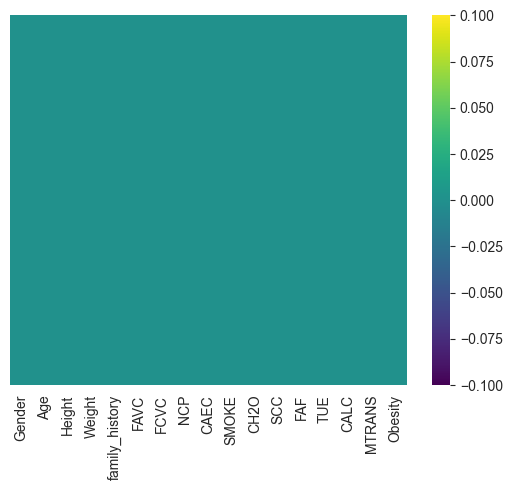

In [629]:
sns.heatmap(df.isnull(), yticklabels = False, cbar = True, cmap = 'viridis')

In [630]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   int32  
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   int32  
 5   FAVC            2111 non-null   int32  
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   int32  
 9   SMOKE           2111 non-null   int32  
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   int32  
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   int32  
 15  MTRANS          2111 non-null   int32  
 16  Obesity         2111 non-null   int32  
dtypes: float64(8), int32(9)
memory us

In [631]:
x=df.drop(['Obesity'],axis=1)
y=df['Obesity']

In [632]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [633]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [634]:
from sklearn.impute import SimpleImputer

# Create an imputer to fill missing values with the mean
imputer = SimpleImputer(strategy='mean')

# Apply the imputer to your feature datasets
x_train_scaled = imputer.fit_transform(x_train_scaled)
x_test_scaled = imputer.transform(x_test_scaled)


In [635]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)
print("\nClassification Report LogisticRegression :\n",classification_report(y_test,y_pred))
print('Accuracy Score:')
print(accuracy_score(y_test, y_pred))



Classification Report LogisticRegression :
               precision    recall  f1-score   support

           0       0.78      0.88      0.83        86
           1       0.81      0.54      0.65        93
           2       0.79      0.66      0.72       102
           3       0.83      0.74      0.78        88
           4       0.90      0.99      0.94        98
           5       0.67      0.62      0.65        88
           6       0.41      0.63      0.50        79

    accuracy                           0.73       634
   macro avg       0.74      0.72      0.72       634
weighted avg       0.75      0.73      0.73       634

Accuracy Score:
0.7255520504731862


In [636]:
x_test_scaled = imputer.transform(x_test_scaled)

# Now make predictions
predictions = model.predict(x_test_scaled)
print(predictions.shape)
predictions

(634,)


array([0, 4, 5, 0, 6, 6, 6, 4, 2, 0, 6, 4, 6, 6, 4, 0, 4, 6, 6, 6, 6, 2,
       4, 6, 0, 6, 6, 4, 4, 6, 4, 6, 5, 6, 1, 4, 6, 1, 0, 1, 2, 6, 6, 1,
       6, 0, 6, 4, 5, 6, 5, 0, 1, 5, 6, 6, 6, 6, 5, 6, 1, 4, 6, 6, 6, 1,
       1, 4, 0, 5, 2, 2, 0, 0, 6, 6, 6, 4, 4, 6, 0, 6, 6, 6, 2, 6, 2, 4,
       6, 6, 6, 6, 1, 2, 6, 6, 1, 2, 1, 6, 6, 2, 4, 6, 6, 2, 0, 4, 4, 3,
       2, 1, 2, 1, 0, 2, 2, 3, 6, 5, 4, 3, 2, 5, 6, 3, 2, 2, 4, 3, 4, 3,
       1, 2, 5, 4, 0, 4, 1, 2, 6, 5, 0, 0, 0, 3, 6, 4, 0, 2, 0, 0, 0, 3,
       2, 5, 6, 6, 0, 0, 1, 1, 2, 0, 6, 0, 3, 5, 5, 6, 5, 3, 3, 4, 2, 6,
       2, 6, 2, 1, 0, 3, 0, 5, 3, 2, 5, 4, 3, 3, 0, 4, 0, 1, 4, 1, 3, 2,
       4, 0, 3, 3, 4, 4, 4, 4, 5, 5, 2, 4, 5, 2, 0, 3, 3, 0, 5, 3, 3, 3,
       4, 6, 3, 5, 3, 2, 0, 4, 1, 0, 5, 4, 1, 5, 5, 2, 2, 2, 6, 0, 6, 6,
       5, 3, 5, 3, 1, 2, 2, 0, 2, 2, 0, 6, 1, 5, 2, 3, 2, 6, 4, 4, 5, 2,
       2, 4, 4, 1, 5, 4, 6, 4, 6, 2, 5, 2, 3, 4, 3, 0, 0, 6, 6, 4, 4, 5,
       2, 6, 0, 3, 2, 5, 0, 3, 0, 5, 3, 3, 6, 2, 1,

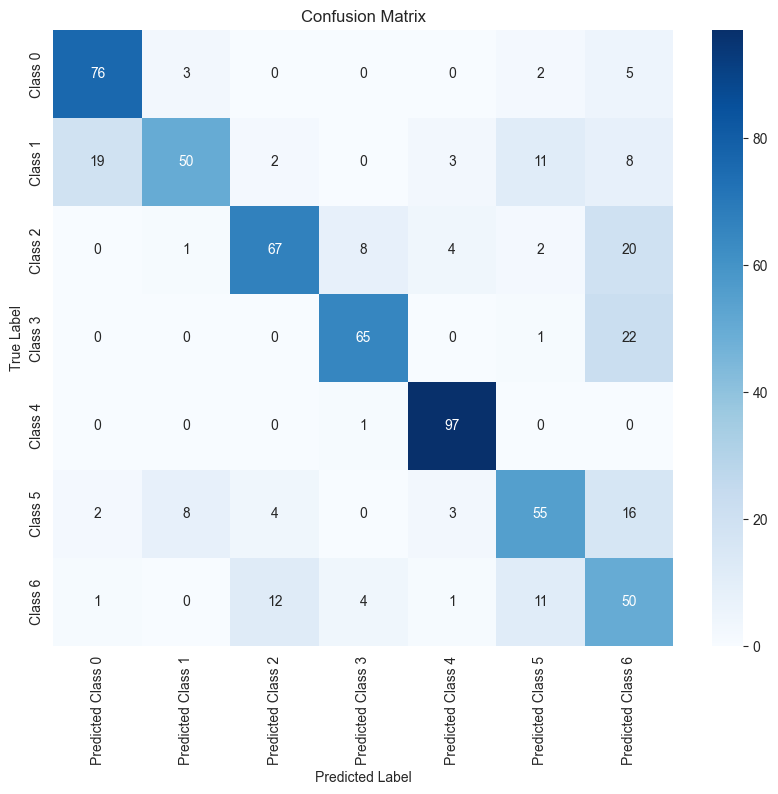

,Predicted Class 0,Predicted Class 1,Predicted Class 2,Predicted Class 3,Predicted Class 4,Predicted Class 5,Predicted Class 6
Class 0,76,3,0,0,0,2,5
Class 1,19,50,2,0,3,11,8
Class 2,0,1,67,8,4,2,20
Class 3,0,0,0,65,0,1,22
Class 4,0,0,0,1,97,0,0
Class 5,2,8,4,0,3,55,16
Class 6,1,0,12,4,1,11,50


In [637]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)  

# Create a DataFrame for better visualization
confusion_df = pd.DataFrame(cm,
             columns = ["Predicted Class " + str(class_name) for class_name in range(7)],
             index = ["Class " + str(class_name) for class_name in range(7)])

# Display the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))  # Adjust figure size if needed
sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues")  
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

confusion_df